# aDDM sampling-recovery check

Tests whether the Commit-4 `hssm.aDDM` class recovers known parameters when sampled on
genuine simulated aDDM data from `addm_data_20251015-163921.npz` (produced by
efficient-fpt's `save_addm_experiment`, which stores both the per-trial data **and** the
true generating parameters).

**True parameters:** `eta=0.7, kappa=0.5, a=2.1, b=0.3, x0=-0.2, sigma=1`.

Two things this notebook deliberately handles:
- The default `aDDMConfig` initial values (`a=1.0, b=2.0`) collapse the boundary near
  `t ≈ a/b ≈ 0.5 s`, but the real RTs reach ~5.7 s — so the default init gives `-inf`
  log-likelihood on ~97% of trials and NUTS cannot start. We therefore **seed init at
  the true params** via `aDDMConfig(params_default=...)`. The init point does not bias
  the posterior (broad in-bounds priors + 1000 trials of data determine it); it only
  lets the sampler start with finite logp.
- Commit 4 cannot compute the post-hoc pointwise log-likelihood (scalar-param kernel),
  so we sample with `idata_kwargs={"log_likelihood": False}`.


In [1]:
import os

# os.environ.setdefault("JAX_PLATFORMS", "cpu")
# os.environ["JAX_PLATFORMS"] = "cuda"
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hssm
from hssm.addm.addm import aDDM
from hssm.addm.config import aDDMConfig
from hssm.addm.likelihoods.builder import make_addm_logp_func
from hssm.addm.likelihoods.jax import set_jax_precision

# Run the FPT quadrature in float64, matching the Commit-4 tests.
set_jax_precision(False)

## 1. Load the data (first 1000 trials)

Keys are slash-delimited group paths (`decision_data/...`, `covariates/...`, `params/...`).

In [13]:
NPZ = "addm_data_20251015-163921.npz"  # this notebook lives next to the file
N = 1000

f = np.load(NPZ, allow_pickle=True)

rt = f["decision_data/rt_data"][:N]
choice = f["decision_data/choice_data"][:N].astype(float)  # +1 / -1
r1 = f["covariates/r1_data"][:N].astype(float)
r2 = f["covariates/r2_data"][:N].astype(float)
flag = f["covariates/flag_data"][:N].astype(int)
sacc2d = f["covariates/sacc_array_data"][:N].astype(float)  # (N, 12), zero-padded
d = f["covariates/d_data"][:N].astype(int)

true = {k: float(f[f"params/{k}"]) for k in ["eta", "kappa", "a", "b", "x0"]}
sigma_true = float(f["params/sigma"])

print("true params:", true, "| sigma:", sigma_true)
print("rt range:", rt.min().round(3), rt.max().round(3), "| d range:", d.min(), d.max())

true params: {'eta': 0.7, 'kappa': 0.5, 'a': 2.1, 'b': 0.3, 'x0': -0.2} | sigma: 1.0
rt range: 0.212 4.886 | d range: 1 10


In [3]:
f['covariates/flag_data']

array([0, 0, 1, ..., 1, 1, 1], shape=(50000,), dtype=int32)

## 2. Build the DataFrame the `aDDM` class accepts

Required columns: `rt, response, r1, r2, flag, d, sigma, sacc_array`. `sigma` must be
constant across trials; `sacc_array` is an **object column** whose cells are per-row
1-D onset arrays (the class re-stacks them internally via `_stack_sacc_array`).

In [4]:
df = pd.DataFrame(
    {
        "rt": rt,
        "response": choice,
        "r1": r1,
        "r2": r2,
        "flag": flag,
        "d": d,
        "sigma": np.full(N, sigma_true),
    }
)
df["sacc_array"] = pd.Series([sacc2d[i] for i in range(N)], index=df.index)

print(df.dtypes)
df.head()

rt            float64
response      float64
r1            float64
r2            float64
flag            int64
d               int64
sigma         float64
sacc_array     object
dtype: object


,rt,response,r1,r2,flag,d,sigma,sacc_array
0,3.508225,1.0,4.0,3.0,0,7,1.0,"[0.0, 0.5629437621599331, 1.3503788625388355, ..."
1,1.070135,-1.0,1.0,1.0,0,3,1.0,"[0.0, 0.6227598037558711, 0.8845474440967768, ..."
2,2.813685,1.0,5.0,3.0,1,4,1.0,"[0.0, 1.4014694404550294, 1.7932155343244867, ..."
3,3.210385,1.0,4.0,3.0,1,5,1.0,"[0.0, 1.0982399708202035, 1.483797606843963, 2..."
4,2.170045,-1.0,2.0,4.0,1,5,1.0,"[0.0, 0.530724636152344, 0.881910856686978, 1...."


In [5]:
df['sacc_array'].iloc[0]

array([0.        , 0.56294376, 1.35037886, 2.07224015, 2.30662596,
       3.1307183 , 3.32310599, 0.        , 0.        , 0.        ,
       0.        , 0.        ])

## 3. Pre-flight: confirm the data is in-support at the true params

Evaluate the per-trial log-likelihood at the true params and assert it is finite (mirrors
`test_smoke_sample`). For contrast we also evaluate at the **default** init values to show
why seeding matters — the default collapses the boundary too early for these RTs.

In [6]:
data_arr = np.column_stack([df["rt"].to_numpy(), df["response"].to_numpy()])
sacc_stacked = aDDM._stack_sacc_array(df["sacc_array"])
logp_fn = make_addm_logp_func()

covariates = (
    df["r1"].to_numpy(),
    df["r2"].to_numpy(),
    df["flag"].to_numpy(),
    sacc_stacked,
    df["d"].to_numpy(),
    df["sigma"].to_numpy(),
)

lp_true = np.asarray(
    logp_fn(data_arr, true["eta"], true["kappa"], true["a"], true["b"], true["x0"], *covariates)
)
lp_default = np.asarray(
    logp_fn(data_arr, 0.3, 1.0, 1.0, 2.0, 0.0, *covariates)  # aDDMConfig default init
)

print(f"true-param logp:    finite={np.all(np.isfinite(lp_true))}, sum={lp_true.sum():.1f}")
print(
    f"default-init logp:  finite={np.all(np.isfinite(lp_default))}, "
    f"n(-inf)={int(np.isneginf(lp_default).sum())}/{N}"
)
assert np.all(np.isfinite(lp_true)), "data not in-support at true params"

/oscar/data/frankmj/azhang/HSSMSpine/repos/HSSM/src/hssm/addm/likelihoods/jax/batch.py:307: UserWarning: Explicitly requested dtype float64 requested in full is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  jnp.full((batch_size, 1), a, dtype=dtype),


true-param logp:    finite=True, sum=-1493.8
default-init logp:  finite=False, n(-inf)=974/1000


In [12]:
import time, jax, numpy as np

# (rebuild these if not in scope)
data_arr = np.column_stack([df["rt"].to_numpy(), df["response"].to_numpy()])
sst = aDDM._stack_sacc_array(df["sacc_array"])
cov = (df["r1"].to_numpy(), df["r2"].to_numpy(), df["flag"].to_numpy(),
       sst, df["d"].to_numpy(), df["sigma"].to_numpy())
true_vals = (0.7, 0.5, 2.1, 0.3, -0.2)   # eta, kappa, a, b, x0

from hssm.addm.likelihoods.builder import make_addm_logp_func
logp = make_addm_logp_func()

# 1) INIT CHECK — is logp finite at the  initial params
lp = np.asarray(logp(data_arr, *true, *cov))
print("init -inf trials:", int(np.isneginf(lp).sum()), "of", len(lp))

# 2) COMPILE TIMING — value
jlogp = jax.jit(lambda *a: logp(*a).sum())
t = time.time(); v = jlogp(data_arr, *true, *cov); v.block_until_ready()
print(f"logp compile+run1: {time.time()-t:.1f}s")
t = time.time(); v = jlogp(data_arr, *true, *cov); v.block_until_ready()
print(f"logp cached run2 : {time.time()-t:.3f}s")

# 3) COMPILE TIMING — gradient 
def s(e,k,a,b,x): return logp(data_arr,e,k,a,b,x,*cov).sum()
g = jax.jit(jax.grad(s, argnums=(0,1,2,3,4)))
t = time.time(); gv = g(*true); jax.block_until_ready(gv)
print(f"grad compile+run1: {time.time()-t:.1f}s")
t = time.time(); gv = g(*true); jax.block_until_ready(gv)
print(f"grad cached run2 : {time.time()-t:.3f}s")


/oscar/data/frankmj/azhang/HSSMSpine/repos/HSSM/src/hssm/addm/likelihoods/jax/batch.py:307: UserWarning: Explicitly requested dtype float64 requested in full is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  jnp.full((batch_size, 1), a, dtype=dtype),


init -inf trials: 0 of 1000
logp compile+run1: 1.2s
logp cached run2 : 0.001s
grad compile+run1: 7.5s
grad cached run2 : 0.008s


## 4. Build the model, seeding initialization at the true params

`params_default` is the deterministic init seed. Setting it to the true values keeps the
sampler's starting point in-support; the priors (default `prior_settings="safe"`, uniform
within the config `bounds`) are unchanged, so this does not bias the posterior.

In [8]:
import bambi as bmb

cfg = aDDMConfig(
    params_default=[0.7, 0.5, 2.1, 0.3, -0.1] # start params at their true values 
)

# model = hssm.aDDM(
#     data=df, model_config=cfg, p_outlier=None,
#     include=[
#         {"name": "eta",   "prior": bmb.Prior("Beta",  alpha=2.0, beta=2.0)},
#         {"name": "kappa", "prior": bmb.Prior("Gamma", alpha=2.0, beta=4.0)},
#         {"name": "a",     "prior": bmb.Prior("Gamma", alpha=4.0, beta=2.0), "bounds": (1.5, 3.0)},
#         {"name": "b",     "prior": bmb.Prior("HalfNormal", sigma=0.15),     "bounds": (0.0, 0.33)},
#         {"name": "x0",    "prior": bmb.Prior("Normal", mu=0.0, sigma=0.5),  "bounds": (-1.0, 1.0)},
#     ],
# )

model = hssm.aDDM(
    data=df, model_config=cfg, p_outlier=None,
    include=[
        {"name": "eta",   "prior": bmb.Prior("Beta",  alpha=2.0, beta=2.0)},
        {"name": "kappa", "prior": bmb.Prior("Gamma", alpha=2.0, beta=4.0)},
        {"name": "a",     "prior": bmb.Prior("Gamma", alpha=4.0, beta=2.0)},
        {"name": "b",     "prior": bmb.Prior("HalfNormal", sigma=0.15)},    
        {"name": "x0",    "prior": bmb.Prior("Normal", mu=0.0, sigma=0.5)}, 
    ],
)

You have specified the `lapse` argument to include a lapse distribution, but `p_outlier` is set to either 0 or None. Your lapse distribution will be ignored.


You supplied a model 'addm', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


## 5. Sample (quick check: tune=500, draws=500, 1 chain)

`idata_kwargs={"log_likelihood": False}` is required on Commit 4. `cores=1` runs the
single chain in-process (avoids JAX-Op/multiprocessing issues).

In [9]:
idata = model.sample(
    draws=500,
    tune=500,
    chains=2,
    cores=1,
    sampler='pymc',
    idata_kwargs={"log_likelihood": False},
)
print("groups:", list(idata.groups()))

Using default initvals. 



Initializing NUTS using adapt_diag...
/oscar/data/frankmj/azhang/HSSMSpine/repos/HSSM/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sequential sampling (2 chains in 1 job)
NUTS: [b, a, x0, kappa, eta]


Output()

/oscar/data/frankmj/azhang/HSSMSpine/repos/HSSM/src/hssm/distribution_utils/jax.py:91: RuntimeWarning: overflow 
encountered in cast
  result = logp(*inputs)

/oscar/data/frankmj/azhang/HSSMSpine/repos/HSSM/src/hssm/distribution_utils/jax.py:183: RuntimeWarning: overflow 
encountered in cast
  results = logp_vjp(*inputs[:-1], gz=inputs[-1])

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 216 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


groups: ['posterior', 'sample_stats', 'observed_data']


## 6. Trace plots with true values overlaid

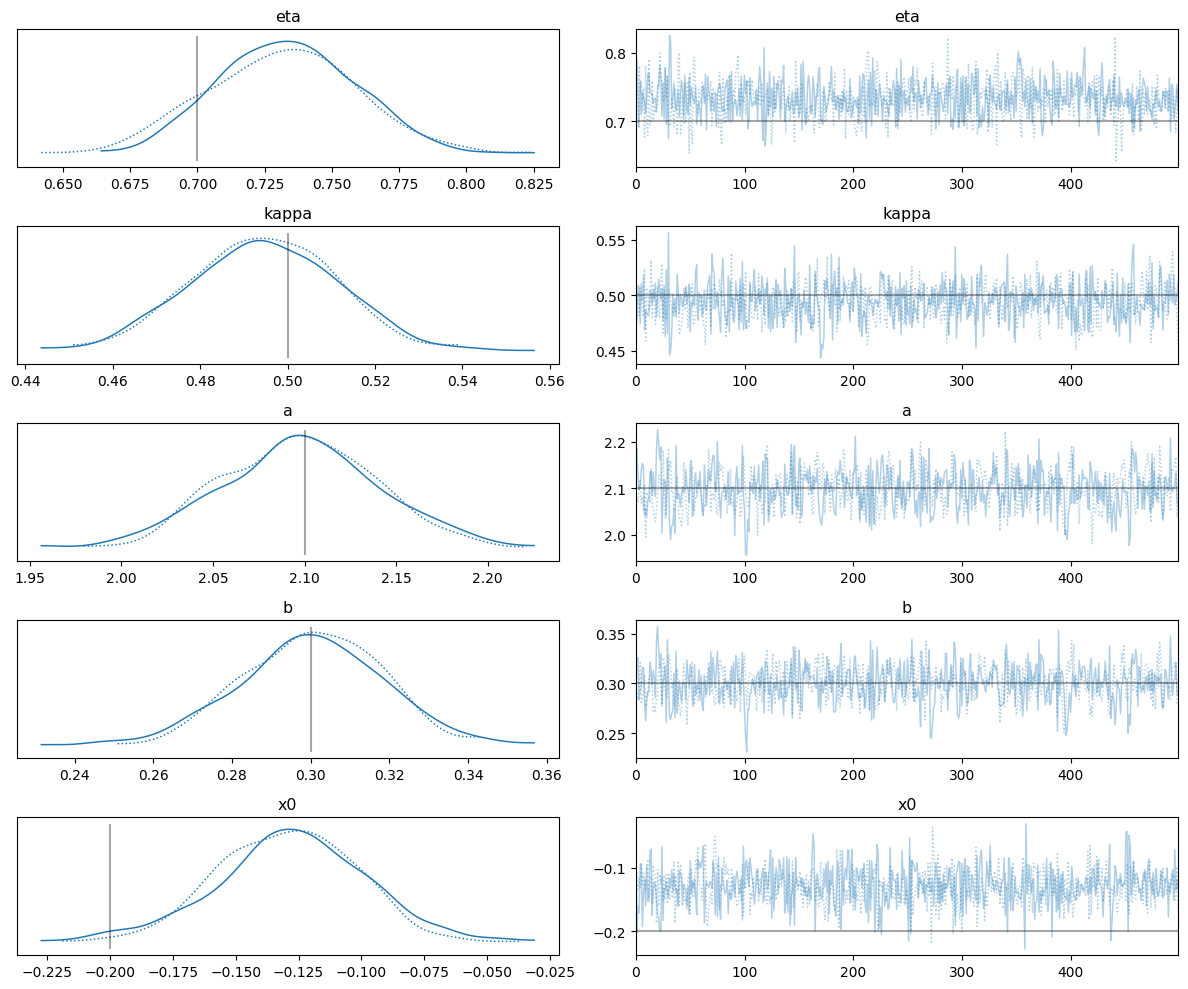

In [14]:
var_names = ["eta", "kappa", "a", "b", "x0"]
az.plot_trace(
    idata,
    var_names=var_names,
    lines=[(k, {}, true[k]) for k in var_names],  # true value drawn on each panel
)
plt.tight_layout()
plt.show()